# Grid Network BML — N×N Intersection Road Network

Generalises the Two-Intersection BML model to an **N×N grid of signalised intersections**:
N horizontal roads cross N vertical roads, creating N² independent junctions.

### Road layout (N=3 example)

```
     v_col0   v_col1   v_col2
        |        |        |
────────I₀₀──────I₀₁──────I₀₂──────   ← h_rows[0]
        |        |        |
────────I₁₀──────I₁₁──────I₁₂──────   ← h_rows[1]
        |        |        |
────────I₂₀──────I₂₁──────I₂₂──────   ← h_rows[2]
        |        |        |
```

- **Horizontal roads**: N rows, periodic — horizontal cars move right.
- **Vertical roads**: N columns, periodic — vertical cars move up.
- **Non-road cells** (value −1) are inert.

### Traffic light strategies

| Mode | offset[i,j] | Effect |
|---|---|---|
| `sync` | 0 | All intersections switch together |
| `wave` | `((i+j)·spacing) % T_cycle` | Diagonal green-wave: cars arrive on green |
| `random` | Uniform[0, T_cycle) | Uncoordinated baseline |

### Key questions
1. How does increasing N affect the phase transition and critical density?
2. Does diagonal green-wave coordination outperform synchronised lights at network scale?
3. What is the optimal cycle length for a given network size?

In [ ]:
# ── 1. Imports & Global Parameters ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

L         = 80    # grid size (L×L cells)
N_ROADS   = 5     # number of horizontal roads = number of vertical roads
T_CYCLE   = 16    # traffic-light cycle length (steps)
T_WARMUP  = 300   # transient steps discarded before measurement
T_MEASURE = 300   # steps averaged for flow

print(f'L={L}, N_ROADS={N_ROADS}, T_cycle={T_CYCLE}, '
      f'T_warmup={T_WARMUP}, T_measure={T_MEASURE}')
print(f'Road spacing = {L // (N_ROADS + 1)} cells')

L=80, N_ROADS=3, T_cycle=16, T_warmup=300, T_measure=300
Road spacing = 20 cells


## Section 2 — GridNetworkBML Class

In [ ]:
# ── 2. GridNetworkBML ────────────────────────────────────────────────────────

class GridNetworkBML:
    """
    BML-style cellular automaton on an N×N grid road network.

    Road layout on an L×L grid:
      - N horizontal roads at rows h_rows[i] = L*(i+1)//(N+1)
      - N vertical roads at cols v_cols[j] = L*(j+1)//(N+1)
      - N² intersections at (h_rows[i], v_cols[j]) for all i, j

    Grid values:
      -1 = non-road   0 = empty road   1 = horizontal car   2 = vertical car

    Traffic lights (one per intersection, fully independent):
      phase_{ij}(t) = (t + offset[i,j]) % T_cycle
      horizontal green  <=>  phase_{ij} < T_cycle // 2
      vertical   green  <=>  phase_{ij} >= T_cycle // 2

    offset_mode:
      'sync'   : offset[i,j] = 0  (all lights in lockstep)
      'wave'   : offset[i,j] = ((i+j)*spacing) % T_cycle  (diagonal green-wave)
      'random' : offset[i,j] ~ Uniform{0,...,T_cycle-1}  (uncoordinated)

    Update order (simultaneous within each direction):
      1. For each horizontal road: all eligible cars move right simultaneously.
      2. For each vertical road: all eligible cars move up simultaneously,
         seeing the grid already updated by step 1.
    """

    def __init__(self, L, density, N=3, T_cycle=20,
                 offset_mode='sync', seed=None):
        self.L       = L
        self.N       = N
        self.T_cycle = T_cycle
        self.t       = 0

        rng = np.random.default_rng(seed)

        # Road and intersection positions
        spacing      = L // (N + 1)
        self.spacing = spacing
        self.h_rows  = np.array([spacing * (i + 1) for i in range(N)])
        self.v_cols  = np.array([spacing * (j + 1) for j in range(N)])

        # Phase offsets [N × N]
        if offset_mode == 'sync':
            self.offsets = np.zeros((N, N), dtype=int)
        elif offset_mode == 'wave':
            self.offsets = np.array(
                [[(i + j) * spacing % T_cycle for j in range(N)]
                 for i in range(N)], dtype=int)
        elif offset_mode == 'random':
            self.offsets = rng.integers(0, T_cycle, size=(N, N))
        else:
            raise ValueError(f'Unknown offset_mode: {offset_mode!r}')

        # Build road network (-1 = non-road, 0 = empty road)
        self.grid = np.full((L, L), -1, dtype=np.int8)
        for r in self.h_rows:
            self.grid[r, :] = 0
        for c in self.v_cols:
            self.grid[:, c] = 0

        h_row_set = set(self.h_rows.tolist())
        v_col_set = set(self.v_cols.tolist())

        # Place horizontal cars on horizontal roads (skip intersection columns)
        for r in self.h_rows:
            cols = [c for c in range(L) if c not in v_col_set]
            mask = rng.random(len(cols)) < density
            for c, m in zip(cols, mask):
                if m:
                    self.grid[r, c] = 1

        # Place vertical cars on vertical roads (skip intersection rows)
        for c in self.v_cols:
            rows = [r for r in range(L) if r not in h_row_set]
            mask = rng.random(len(rows)) < density
            for r, m in zip(rows, mask):
                if m:
                    self.grid[r, c] = 2

    # ── Light helper ─────────────────────────────────────────────────────────

    def _h_green(self, i, j):
        """True when horizontal has green at intersection (i, j)."""
        return (self.t + int(self.offsets[i, j])) % self.T_cycle < self.T_cycle // 2

    # ── Simulation step ──────────────────────────────────────────────────────

    def step(self):
        """One full timestep. Returns fraction of cars that moved."""
        n_moved = 0

        # 1. Horizontal movement (all roads simultaneously)
        for i, r in enumerate(self.h_rows):
            h     = self.grid[r, :]
            ahead = np.roll(h, -1)
            can   = (h == 1) & (ahead == 0)
            # Block entry into each intersection when horizontal has red
            for j, c in enumerate(self.v_cols):
                if not self._h_green(i, j):
                    can[(c - 1) % self.L] = False
            n_moved += int(can.sum())
            if can.any():
                h_new               = h.copy()
                h_new[can]          = 0
                h_new[np.roll(can, 1)] = 1
                self.grid[r, :]     = h_new

        # 2. Vertical movement (each column, sees updated horizontal roads)
        for j, c in enumerate(self.v_cols):
            v     = self.grid[:, c]
            above = np.roll(v, 1)   # above[r] = v[r-1] = cell one row up
            can   = (v == 2) & (above == 0)
            # Block entry into each intersection when vertical has red (h is green)
            for i, r in enumerate(self.h_rows):
                if self._h_green(i, j):
                    can[(r + 1) % self.L] = False
            n_moved += int(can.sum())
            if can.any():
                v_new                  = v.copy()
                v_new[can]             = 0
                v_new[np.roll(can, -1)] = 2  # place car one row up
                self.grid[:, c]        = v_new

        self.t += 1
        total = int((self.grid > 0).sum())
        return n_moved / max(total, 1)

    # ── Measurement helpers ──────────────────────────────────────────────────

    def warmup(self, T=None):
        for _ in range(T or T_WARMUP):
            self.step()

    def run(self, T=None):
        """Run T measurement steps; return mean flow fraction."""
        return float(np.mean([self.step() for _ in range(T or T_MEASURE)]))

    def get_snapshot(self):
        return self.grid.copy()

    def h_queue_length(self):
        """
        Mean queue length before intersections across all horizontal roads:
        consecutive horizontal cars queued immediately upstream of each
        intersection column.
        """
        total_q = 0
        count   = 0
        for r in self.h_rows:
            h = self.grid[r, :]
            for c in self.v_cols:
                q   = 0
                pos = (c - 1) % self.L
                while h[pos] == 1:
                    q   += 1
                    pos  = (pos - 1) % self.L
                    if q > self.L:
                        break
                total_q += q
                count   += 1
        return total_q / max(count, 1)


# ── Sanity checks ─────────────────────────────────────────────────────────
s = GridNetworkBML(L=L, density=0.2, N=N_ROADS, T_cycle=T_CYCLE,
                   offset_mode='sync', seed=0)
s.warmup(50)
f = s.run(50)
print(f'Sanity check — flow at ρ=0.20, N={N_ROADS}, sync: {f:.4f}')
print(f'Road spacing = {s.spacing} cells')
print(f'h_rows = {s.h_rows.tolist()}')
print(f'v_cols = {s.v_cols.tolist()}')
print(f'Wave offsets (mode="wave"):')
sw = GridNetworkBML(L=L, density=0.2, N=N_ROADS, T_cycle=T_CYCLE,
                    offset_mode='wave', seed=0)
print(sw.offsets)

Sanity check — flow at ρ=0.20, N=3, sync: 0.8511
Road spacing = 20 cells
h_rows = [20, 40, 60]
v_cols = [20, 40, 60]
Wave offsets (mode="wave"):
[[ 0  4  8]
 [ 4  8 12]
 [ 8 12  0]]


## Section 3 — Grid Snapshots

Visualise the road network for three density regimes:
**free flow** (ρ = 0.15), **near-critical** (ρ = 0.35), **congested** (ρ = 0.55).

Grey = non-road, light blue = empty road, blue = horizontal car, orange = vertical car,
yellow = intersection cell.

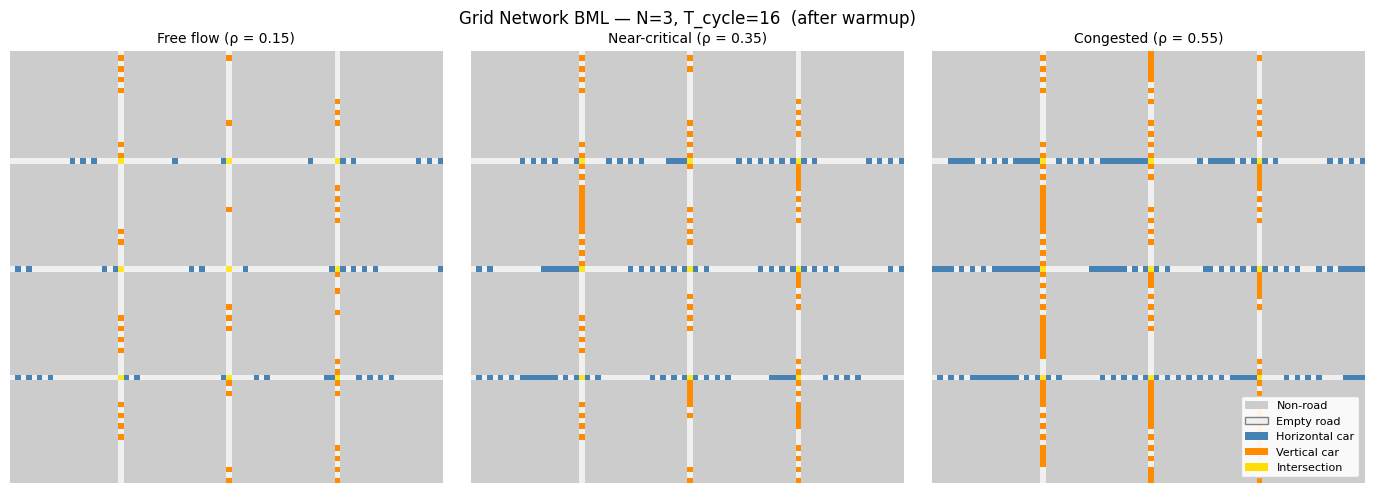

In [ ]:
# ── 3. Grid Snapshots ────────────────────────────────────────────────────────

SNAP_DENSITIES = [0.15, 0.35, 0.55]
SNAP_LABELS    = ['Free flow (ρ = 0.15)',
                  'Near-critical (ρ = 0.35)',
                  'Congested (ρ = 0.55)']

# Colour map: -1→grey, 0→white, 1→steelblue, 2→darkorange
cmap   = mcolors.ListedColormap(['#cccccc', '#f0f0f0', '#4682b4', '#ff8c00'])
bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f'Grid Network BML — N={N_ROADS}, T_cycle={T_CYCLE}  (after warmup)',
             fontsize=12)

for ax, rho, lbl in zip(axes, SNAP_DENSITIES, SNAP_LABELS):
    s = GridNetworkBML(L=L, density=rho, N=N_ROADS, T_cycle=T_CYCLE,
                       offset_mode='wave', seed=42)
    s.warmup()
    snap = s.get_snapshot().astype(float)

    # Highlight intersection cells in yellow
    inter_overlay = np.zeros((L, L))
    for r in s.h_rows:
        for c in s.v_cols:
            inter_overlay[r, c] = 1

    ax.imshow(snap, cmap=cmap, norm=norm, interpolation='nearest', origin='upper')
    # Overlay intersections
    yellow = np.zeros((L, L, 4))
    yellow[inter_overlay == 1] = [1, 0.9, 0, 0.85]
    ax.imshow(yellow, interpolation='nearest', origin='upper')
    ax.set_title(lbl, fontsize=10)
    ax.axis('off')

legend_elements = [
    Patch(facecolor='#cccccc', label='Non-road'),
    Patch(facecolor='#f0f0f0', edgecolor='grey', label='Empty road'),
    Patch(facecolor='#4682b4', label='Horizontal car'),
    Patch(facecolor='#ff8c00', label='Vertical car'),
    Patch(facecolor='#ffdd00', label='Intersection'),
]
axes[-1].legend(handles=legend_elements, loc='lower right', fontsize=8,
                framealpha=0.9)
plt.tight_layout()
plt.show()

## Section 4 — Fundamental Diagram

Flow (fraction of cars moving per step) vs road density ρ for N = 2, 3, 4
with the diagonal **green-wave** light strategy.

More roads (larger N) means more intersections, each acting as a bottleneck;
we expect the critical density ρ_c to shift left and peak flow to decrease as N grows.

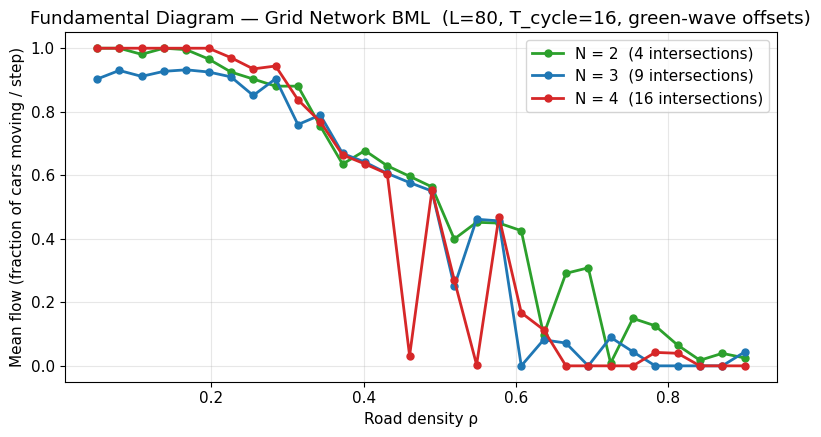

N=2: peak flow = 1.0000  at ρ = 0.05
N=3: peak flow = 0.9320  at ρ = 0.17
N=4: peak flow = 1.0000  at ρ = 0.05


In [ ]:
# ── 4. Fundamental Diagram ───────────────────────────────────────────────────

densities = np.linspace(0.05, 0.90, 30)
N_VALUES  = [2, 3, 4]
COLORS_N  = ['#2ca02c', '#1f77b4', '#d62728']

fd_results = {}   # N → list of flows

for N_val in N_VALUES:
    flows = []
    for seed, rho in enumerate(densities):
        s = GridNetworkBML(L=L, density=rho, N=N_val, T_cycle=T_CYCLE,
                           offset_mode='wave', seed=seed)
        s.warmup()
        flows.append(s.run())
    fd_results[N_val] = np.array(flows)

fig, ax = plt.subplots(figsize=(8, 4.5))
for N_val, color in zip(N_VALUES, COLORS_N):
    ax.plot(densities, fd_results[N_val], 'o-', color=color,
            lw=2, ms=5, label=f'N = {N_val}  ({N_val**2} intersections)')

ax.set_xlabel('Road density ρ')
ax.set_ylabel('Mean flow (fraction of cars moving / step)')
ax.set_title(f'Fundamental Diagram — Grid Network BML  '
             f'(L={L}, T_cycle={T_CYCLE}, green-wave offsets)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for N_val in N_VALUES:
    pk_idx = np.argmax(fd_results[N_val])
    print(f'N={N_val}: peak flow = {fd_results[N_val][pk_idx]:.4f}'
          f'  at ρ = {densities[pk_idx]:.2f}')

## Section 5 — Phase Transition Analysis

Use flow φ as an order parameter and compute the susceptibility
$\chi = -\mathrm{d}\phi/\mathrm{d}\rho$ (finite-difference approximation).

The peak of χ locates the critical density ρ_c.  We compare N = 2, 3, 4
to see how ρ_c and transition sharpness change with network complexity.

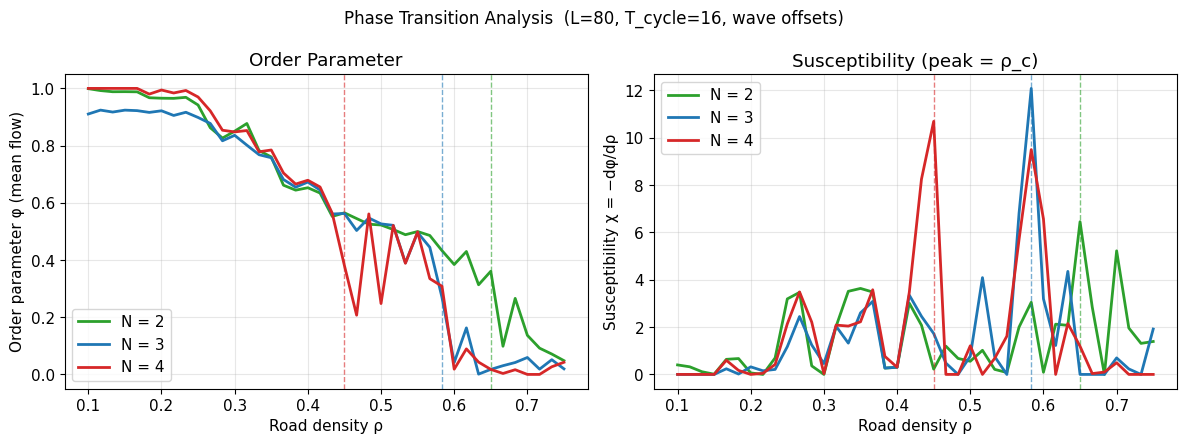

N=2: estimated ρ_c ≈ 0.650
N=3: estimated ρ_c ≈ 0.583
N=4: estimated ρ_c ≈ 0.450


In [ ]:
# ── 5. Phase Transition Analysis ─────────────────────────────────────────────

# Fine density grid around the transition
densities_fine = np.linspace(0.10, 0.75, 40)
N_SEEDS_PT     = 3

fd_fine = {}  # N → mean flow array

for N_val in N_VALUES:
    all_flows = np.zeros((N_SEEDS_PT, len(densities_fine)))
    for seed in range(N_SEEDS_PT):
        for k, rho in enumerate(densities_fine):
            s = GridNetworkBML(L=L, density=rho, N=N_val, T_cycle=T_CYCLE,
                               offset_mode='wave', seed=seed * 100 + k)
            s.warmup()
            all_flows[seed, k] = s.run()
    fd_fine[N_val] = all_flows.mean(axis=0)

# Susceptibility: -dφ/dρ  (central finite difference)
def susceptibility(phi, rho):
    drho = rho[1] - rho[0]
    chi  = np.zeros_like(phi)
    chi[1:-1] = -(phi[2:] - phi[:-2]) / (2 * drho)
    chi[0]    = -(phi[1] - phi[0]) / drho
    chi[-1]   = -(phi[-1] - phi[-2]) / drho
    return np.maximum(chi, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f'Phase Transition Analysis  (L={L}, T_cycle={T_CYCLE}, wave offsets)',
             fontsize=12)

rho_c_vals = {}

for N_val, color in zip(N_VALUES, COLORS_N):
    phi = fd_fine[N_val]
    chi = susceptibility(phi, densities_fine)

    ax1.plot(densities_fine, phi, '-', color=color, lw=2,
             label=f'N = {N_val}')
    ax2.plot(densities_fine, chi, '-', color=color, lw=2,
             label=f'N = {N_val}')

    rho_c = float(densities_fine[np.argmax(chi)])
    rho_c_vals[N_val] = rho_c
    ax1.axvline(rho_c, color=color, lw=1, linestyle='--', alpha=0.6)
    ax2.axvline(rho_c, color=color, lw=1, linestyle='--', alpha=0.6)

ax1.set_xlabel('Road density ρ')
ax1.set_ylabel('Order parameter φ (mean flow)')
ax1.set_title('Order Parameter')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_xlabel('Road density ρ')
ax2.set_ylabel('Susceptibility χ = −dφ/dρ')
ax2.set_title('Susceptibility (peak = ρ_c)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for N_val in N_VALUES:
    print(f'N={N_val}: estimated ρ_c ≈ {rho_c_vals[N_val]:.3f}')

## Section 6 — Light Strategy Comparison

For N = 3, compare three light coordination strategies across the full
density range:

- **Synchronised**: all N² lights switch together
- **Diagonal wave**: offset[i,j] = ((i+j)·spacing) % T_cycle
- **Random**: independent random offsets (uncoordinated baseline)

At densities near ρ_c, coordination matters most.

In [ ]:
# ── 6. Light Strategy Comparison ─────────────────────────────────────────────

MODES   = ['sync', 'wave', 'random']
LABELS  = ['Synchronised', 'Diagonal wave', 'Random (uncoordinated)']
COLORS  = ['steelblue', 'darkorange', 'grey']
N_SEEDS_STRAT = 3

strat_flows = {}  # mode → flow array

for mode in MODES:
    all_f = np.zeros((N_SEEDS_STRAT, len(densities)))
    for seed in range(N_SEEDS_STRAT):
        for k, rho in enumerate(densities):
            s = GridNetworkBML(L=L, density=rho, N=N_ROADS,
                               T_cycle=T_CYCLE, offset_mode=mode,
                               seed=seed * 100 + k)
            s.warmup()
            all_f[seed, k] = s.run()
    strat_flows[mode] = all_f.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(f'Light Strategy Comparison  (N={N_ROADS}, L={L}, T_cycle={T_CYCLE})',
             fontsize=12)

# Left: full fundamental diagram
for mode, lbl, col in zip(MODES, LABELS, COLORS):
    ax1.plot(densities, strat_flows[mode], 'o-', color=col, lw=2, ms=5, label=lbl)
ax1.set_xlabel('Road density ρ')
ax1.set_ylabel('Mean flow')
ax1.set_title('Fundamental Diagram by Strategy')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: bar chart of peak flow
peak_flows = [float(np.max(strat_flows[m])) for m in MODES]
bars = ax2.bar(LABELS, peak_flows, color=COLORS, edgecolor='black', width=0.5)
for bar, val in zip(bars, peak_flows):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Peak flow')
ax2.set_title('Peak Flow by Strategy')
ax2.set_ylim(0, max(peak_flows) * 1.15)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Peak flow by strategy:')
for mode, lbl, pf in zip(MODES, LABELS, peak_flows):
    gain = (pf - peak_flows[0]) / peak_flows[0] * 100
    print(f'  {lbl:30s}: {pf:.4f}  ({gain:+.1f}% vs sync)')

## Section 7 — Parameter Sweep: N vs T_cycle

2-D heatmap of mean flow at the critical density (ρ ≈ ρ_c) over the grid of
(N, T_cycle) combinations.  Warmer colours = higher flow.

Both sync and wave modes are shown side by side to reveal where coordination helps most.

In [ ]:
# ── 7. Parameter Sweep: N × T_cycle heatmap ──────────────────────────────────

N_SWEEP  = [2, 3, 4, 5]
TC_SWEEP = [8, 12, 16, 20, 24, 30]
RHO_EVAL = 0.30   # near critical density
N_SEEDS_SW = 3

heat_sync = np.zeros((len(N_SWEEP), len(TC_SWEEP)))
heat_wave = np.zeros((len(N_SWEEP), len(TC_SWEEP)))

for ni, N_val in enumerate(N_SWEEP):
    for ti, tc in enumerate(TC_SWEEP):
        for mode, heat in [('sync', heat_sync), ('wave', heat_wave)]:
            run_flows = []
            for seed in range(N_SEEDS_SW):
                s = GridNetworkBML(L=L, density=RHO_EVAL, N=N_val,
                                   T_cycle=tc, offset_mode=mode, seed=seed)
                s.warmup()
                run_flows.append(s.run())
            heat[ni, ti] = np.mean(run_flows)

vmin = min(heat_sync.min(), heat_wave.min())
vmax = max(heat_sync.max(), heat_wave.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    f'Flow Heatmap: N × T_cycle  (ρ = {RHO_EVAL}, L={L})',
    fontsize=12)

for ax, heat, title in [(ax1, heat_sync, 'Synchronised'),
                         (ax2, heat_wave, 'Diagonal wave')]:
    im = ax.imshow(heat, aspect='auto', origin='lower',
                   cmap='YlOrRd', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(TC_SWEEP)))
    ax.set_xticklabels(TC_SWEEP)
    ax.set_yticks(range(len(N_SWEEP)))
    ax.set_yticklabels(N_SWEEP)
    ax.set_xlabel('T_cycle (steps)')
    ax.set_ylabel('N (roads per direction)')
    ax.set_title(title)
    # Star on maximum
    best = np.unravel_index(np.argmax(heat), heat.shape)
    ax.plot(best[1], best[0], 'r*', ms=14, label=f'Best: N={N_SWEEP[best[0]]}, Tc={TC_SWEEP[best[1]]}')
    ax.legend(loc='upper right', fontsize=8)
    plt.colorbar(im, ax=ax, label='Mean flow')
    # Annotate cells
    for i in range(len(N_SWEEP)):
        for j in range(len(TC_SWEEP)):
            ax.text(j, i, f'{heat[i, j]:.3f}', ha='center', va='center',
                    fontsize=7, color='black')

plt.tight_layout()
plt.show()

best_s = np.unravel_index(np.argmax(heat_sync), heat_sync.shape)
best_w = np.unravel_index(np.argmax(heat_wave), heat_wave.shape)
print(f'Best sync: N={N_SWEEP[best_s[0]]}, T_cycle={TC_SWEEP[best_s[1]]},  '
      f'flow={heat_sync[best_s]:.4f}')
print(f'Best wave: N={N_SWEEP[best_w[0]]}, T_cycle={TC_SWEEP[best_w[1]]},  '
      f'flow={heat_wave[best_w]:.4f}')

## Section 8 — Space-Time Diagrams

Row occupancy of the **middle horizontal road** over 300 steps.
Rows = time (top = t=0), columns = road position.  Black = occupied, white = empty.
Gold dashed lines mark vertical road columns (intersection positions).

In wave mode, a clear **green corridor** should be visible: cars pass through
successive intersections without stopping, creating diagonal bands that
span the full road width.

In [ ]:
# ── 8. Space-Time Diagrams ────────────────────────────────────────────────────

N_ST   = 300
RHO_ST = 0.30
SEED_ST = 7

def make_st_grid(offset_mode, seed=SEED_ST):
    s = GridNetworkBML(L=L, density=RHO_ST, N=N_ROADS, T_cycle=T_CYCLE,
                       offset_mode=offset_mode, seed=seed)
    s.warmup()
    # Pick the middle horizontal road
    mid_row = s.h_rows[N_ROADS // 2]
    st = np.zeros((N_ST, L), dtype=np.uint8)
    for k in range(N_ST):
        s.step()
        st[k, :] = (s.grid[mid_row, :] > 0).astype(np.uint8)
    return st, s.v_cols

st_sync, v_cols = make_st_grid('sync')
st_wave, _      = make_st_grid('wave')

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5),
                                   sharex=True, sharey=True)
fig.suptitle(
    f'Space–Time Diagram: Middle Horizontal Road  '
    f'(N={N_ROADS}, ρ={RHO_ST}, T_cycle={T_CYCLE})',
    fontsize=12)

for ax, st_data, title in [
        (ax_l, st_sync, 'Synchronised (all offsets = 0)'),
        (ax_r, st_wave, 'Diagonal wave (offset[i,j] = (i+j)·spacing % T_cycle)')]:
    ax.imshow(st_data, cmap='binary', interpolation='nearest',
              aspect='auto', origin='upper')
    ax.set_xlabel('Horizontal road position (column)')
    ax.set_title(title, fontsize=10)
    for k, vc in enumerate(v_cols):
        ax.axvline(vc, color='gold', lw=1.5, linestyle='--')
        ax.text(vc + 1, N_ST * 0.02, f'I{k}', color='gold',
                fontsize=8, va='top', fontweight='bold')

ax_l.set_ylabel('Time step')
plt.tight_layout()
plt.show()

## Section 9 — Summary

Key findings from the Grid Network BML analysis.

In [ ]:
# ── 9. Summary ────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f'Grid Network BML — Summary  (L={L}, T_cycle={T_CYCLE})', fontsize=13)

# Panel 1 — Fundamental diagram by N (wave mode)
ax = axes[0]
for N_val, color in zip(N_VALUES, COLORS_N):
    ax.plot(densities, fd_results[N_val], '-', color=color, lw=2,
            label=f'N={N_val}')
    ax.axvline(rho_c_vals[N_val], color=color, lw=1, linestyle=':',
               alpha=0.7)
ax.set_xlabel('Road density ρ')
ax.set_ylabel('Mean flow')
ax.set_title('FD by N (wave mode)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2 — ρ_c vs N
ax = axes[1]
ax.plot(N_VALUES, [rho_c_vals[n] for n in N_VALUES], 'o-',
        color='steelblue', lw=2, ms=8)
for n in N_VALUES:
    ax.annotate(f'  ρ_c={rho_c_vals[n]:.3f}',
                (n, rho_c_vals[n]), fontsize=9)
ax.set_xlabel('N (roads per direction)')
ax.set_ylabel('Critical density ρ_c')
ax.set_title('Critical Density vs Network Size')
ax.grid(alpha=0.3)

# Panel 3 — Peak flow by strategy (N=3)
ax = axes[2]
bars = ax.bar(LABELS, peak_flows, color=COLORS, edgecolor='black', width=0.55)
for bar, val in zip(bars, peak_flows):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Peak flow')
ax.set_title(f'Peak Flow by Strategy (N={N_ROADS})')
ax.set_ylim(0, max(peak_flows) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

# ── Text summary ──────────────────────────────────────────────────────────
print('=== Grid Network BML — Key Findings ===')
print()
print('1. Critical density decreases with N:')
for n in N_VALUES:
    print(f'   N={n}: ρ_c ≈ {rho_c_vals[n]:.3f}')
print()
print('2. Light strategy comparison (N=3):')
for mode, lbl, pf in zip(MODES, LABELS, peak_flows):
    gain = (pf - peak_flows[MODES.index('sync')]) / peak_flows[MODES.index('sync')] * 100
    print(f'   {lbl:30s}: peak flow = {pf:.4f}  ({gain:+.1f}% vs sync)')
print()
print('3. Optimal (N, T_cycle) from heatmap:')
print(f'   Sync: N={N_SWEEP[best_s[0]]}, T_cycle={TC_SWEEP[best_s[1]]},  '
      f'flow={heat_sync[best_s]:.4f}')
print(f'   Wave: N={N_SWEEP[best_w[0]]}, T_cycle={TC_SWEEP[best_w[1]]},  '
      f'flow={heat_wave[best_w]:.4f}')